# EDA — Aspect-Based Sentiment Analysis
### French Restaurant Reviews · CentraleSupélec NLP Project 2025–26

Run from the `src/` directory (or adjust `DATA_DIR` below).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

ASPECTS = ['Price', 'Food', 'Service']
LABELS  = ['Positive', 'Negative', 'Mixed', 'No Opinion']
DATA_DIR = '../data/'

COLORS = {
    'Positive':   '#3B6D11',
    'Negative':   '#A32D2D',
    'Mixed':      '#BA7517',
    'No Opinion': '#185FA5',
}

## 1 · Load data

In [2]:
def load_tsv(path):
    return pd.read_csv(path, sep=r' *\t *', encoding='utf-8', engine='python')

train = load_tsv(DATA_DIR + 'ftdataset_train.tsv')
val   = load_tsv(DATA_DIR + 'ftdataset_val.tsv')

try:
    test = load_tsv(DATA_DIR + 'ftdataset_test.tsv')
    print(f'Test set loaded: {len(test)} rows')
except FileNotFoundError:
    test = None
    print('No test set found (expected — held out).')

print(f'Train: {len(train)} rows | Val: {len(val)} rows')
print(f'Columns: {list(train.columns)}')

No test set found (expected — held out).
Train: 4009 rows | Val: 600 rows
Columns: ['Restaurant', 'Price', 'Food', 'Service', 'Review']


In [3]:
train.head(100)

,Restaurant,Price,Food,Service,Review
0,Brasserie Chavant Grenoble,No Opinion,Mixed,Negative,Trop trop long. Repas correct et pas exceptionnel Salle a l etage pas vraiement adapte por le service d un groupe te...
1,Bistrot André - Grenoble,No Opinion,No Opinion,Mixed,"Très bon, cette fois ci la climatisation était fonctionnelle et le service organisé. Il faudrait toutefois suggérer ..."
2,"""""""""""""""Terre Adélice - Lyon""""""""""""""",No Opinion,Positive,Negative,"""""""""""""""Bonnes glaces mais glacier pas sympa. Mes petits enfants fatigués se sont assis pour manger leur boule de gla..."
3,Le Marrakech - Annecy,Mixed,Positive,Positive,j'étais déjà allé seul dans ce restaurant que j'avais trouve bien. nous sommes retourner en couple et c'était toujou...
4,Les Jardins de Sainte-Cécile - Grenoble,No Opinion,Positive,No Opinion,"Trois fois dans ce restaurant, trois fois où nous avons passé un superbe moment. Cuisine raffinée gastro et élégamme..."
...,...,...,...,...,...
95,Bistrot André - Grenoble,No Opinion,Positive,Positive,"Repas exceptionnel avec un service à la hauteur des plats , Je recommande qui veulent se faire plaisir avec une cui..."
96,Le Gratin Dauphinois - Grenoble,Positive,Positive,Positive,"Accueil chaleureux, plats copieux et délicieux. Bravo!! Une déco sympa et originale. A refaire et vite!!"
97,"""""""""""""""Chateau de la commanderie - Grenoble""""""""""""""",Positive,Positive,Positive,"""""""""""""""Un très bon cadre, beaucoup de cachet. Accueil chaleureux par le maître d'hôtel avec un bon conseil pour le v..."
98,La Peña Andaluza - Grenoble,No Opinion,Mixed,Mixed,"Bonne nourriture et serveur agréable. Cependant comme dit dans des précédents commentaires, service ultraaaa long et..."


In [ ]:
i = 100

row = train.loc[i]

print(f'price : {row["Price"]}')
print(f'Food : {row["Food"]}')
print(f'Service : {row["Service"]}')


row['Review']

price : No Opinion
Food : Positive
Service : Negative


'"""""""Bonnes glaces mais glacier pas sympa. Mes petits enfants fatigués se sont assis pour manger leur boule de glace et on s’est fait virer, alors que la terrasse était vide."""""""'

In [4]:
# Basic info
print('=== TRAIN ===')
print(train.dtypes)
print('\nNull values:')
print(train.isnull().sum())

=== TRAIN ===
Restaurant    str
Price         str
Food          str
Service       str
Review        str
dtype: object

Null values:
Restaurant    0
Price         0
Food          0
Service       0
Review        0
dtype: int64


## 2 · Raw label audit (before normalisation)

In [5]:
# Inspect every unique raw value per aspect column — spot noise before cleaning
for split_name, df in [('TRAIN', train), ('VAL', val)]:
    print(f'\n{'='*40}')
    print(f'  {split_name}')
    print(f'{'='*40}')
    for asp in ASPECTS:
        counts = df[asp].value_counts(dropna=False)
        print(f'\n{asp}:')
        print(counts.to_string())


  TRAIN

Price:
Price
No Opinion     2564
Positive        728
Negative        562
Mixed           154
Positive#NE       1

Food:
Food
Positive      2773
Negative       536
No Opinion     383
Mixed          317

Service:
Service
Positive      2362
No Opinion     807
Negative       651
Mixed          189

  VAL

Price:
Price
No Opinion    387
Positive      116
Negative       80
Mixed          17

Food:
Food
Positive      420
Negative       75
No Opinion     59
Mixed          46

Service:
Service
Positive      340
No Opinion    120
Negative      114
Mixed          26


In [6]:
# Flag values that are NOT in the expected label set
VALID = set(LABELS)

def normalize_label(raw):
    cleaned = str(raw).strip().split('#')[0].strip()
    return cleaned if cleaned in VALID else 'No Opinion'

for split_name, df in [('TRAIN', train), ('VAL', val)]:
    print(f'\n{split_name} — unrecognised raw labels (→ silently become "No Opinion"):')
    for asp in ASPECTS:
        raw_cleaned = df[asp].apply(lambda x: str(x).strip().split('#')[0].strip())
        unknown = raw_cleaned[~raw_cleaned.isin(VALID)]
        if len(unknown):
            print(f'  {asp}: {dict(unknown.value_counts())}')
        else:
            print(f'  {asp}: none')


TRAIN — unrecognised raw labels (→ silently become "No Opinion"):
  Price: none
  Food: none
  Service: none

VAL — unrecognised raw labels (→ silently become "No Opinion"):
  Price: none
  Food: none
  Service: none


## 3 · Apply normalisation & build clean dataframes

In [7]:
for df in [train, val]:
    for asp in ASPECTS:
        df[asp + '_clean'] = df[asp].apply(normalize_label)

CLEAN = [a + '_clean' for a in ASPECTS]
train[ASPECTS + CLEAN].head()

,Price,Food,Service,Price_clean,Food_clean,Service_clean
0,No Opinion,Mixed,Negative,No Opinion,Mixed,Negative
1,No Opinion,No Opinion,Mixed,No Opinion,No Opinion,Mixed
2,No Opinion,Positive,Negative,No Opinion,Positive,Negative
3,Mixed,Positive,Positive,Mixed,Positive,Positive
4,No Opinion,Positive,No Opinion,No Opinion,Positive,No Opinion


## 4 · Class distribution per aspect

In [8]:
# Counts table
for split_name, df in [('TRAIN', train), ('VAL', val)]:
    print(f'\n{split_name} — normalised label counts:')
    rows = {}
    for asp in ASPECTS:
        counts = df[asp + '_clean'].value_counts().reindex(LABELS, fill_value=0)
        rows[asp] = counts
    tbl = pd.DataFrame(rows).T
    tbl['Total'] = tbl.sum(axis=1)
    display(tbl)


TRAIN — normalised label counts:


,Positive,Negative,Mixed,No Opinion,Total
Price,729,562,154,2564,4009
Food,2773,536,317,383,4009
Service,2362,651,189,807,4009



VAL — normalised label counts:


,Positive,Negative,Mixed,No Opinion,Total
Price,116,80,17,387,600
Food,420,75,46,59,600
Service,340,114,26,120,600


In [9]:
# Percentage distribution per aspect
print('TRAIN — label distribution (%):')
rows = {}
for asp in ASPECTS:
    pct = train[asp + '_clean'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100
    rows[asp] = pct.round(1)
display(pd.DataFrame(rows).T)

TRAIN — label distribution (%):


,Positive,Negative,Mixed,No Opinion
Price,18.20,14.00,3.80,64.00
Food,69.20,13.40,7.90,9.60
Service,58.90,16.20,4.70,20.10


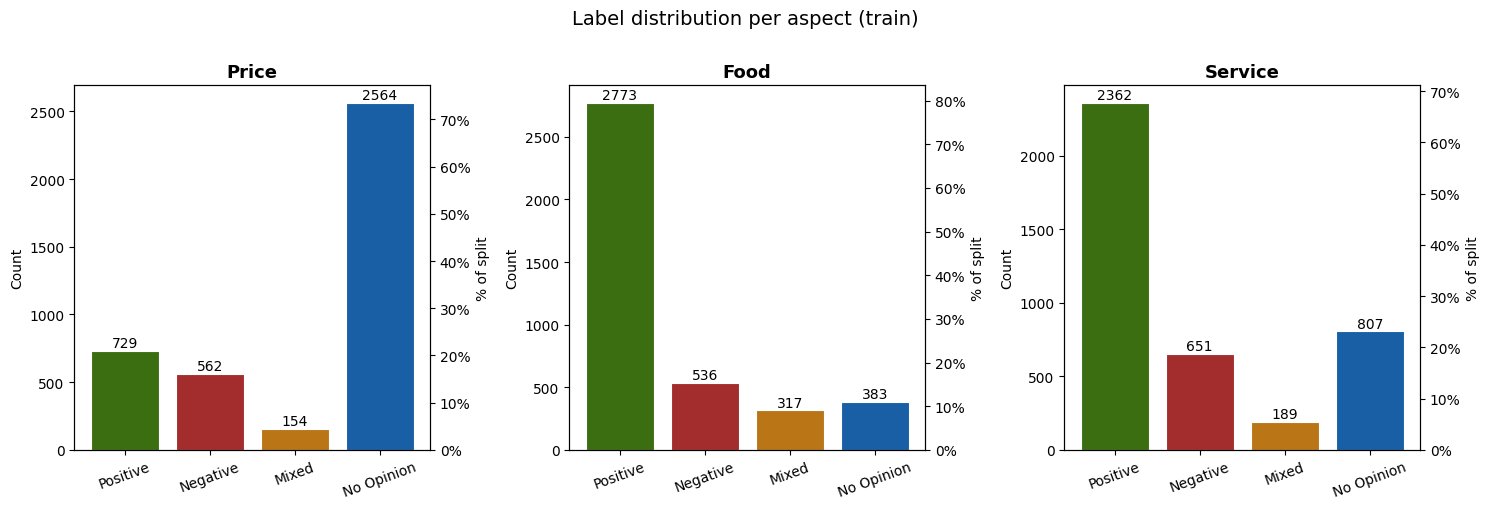

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Label distribution per aspect (train)', fontsize=14, y=1.01)

for ax, asp in zip(axes, ASPECTS):
    counts = train[asp + '_clean'].value_counts().reindex(LABELS, fill_value=0)
    colors = [COLORS[l] for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(asp, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
    for bar, value in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(value), ha='center', va='bottom', fontsize=10)
    total = counts.sum()
    ax2 = ax.twinx()
    ax2.set_ylim(0, ax.get_ylim()[1] / total * 100 * 1.15)
    ax2.set_ylabel('% of split')
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

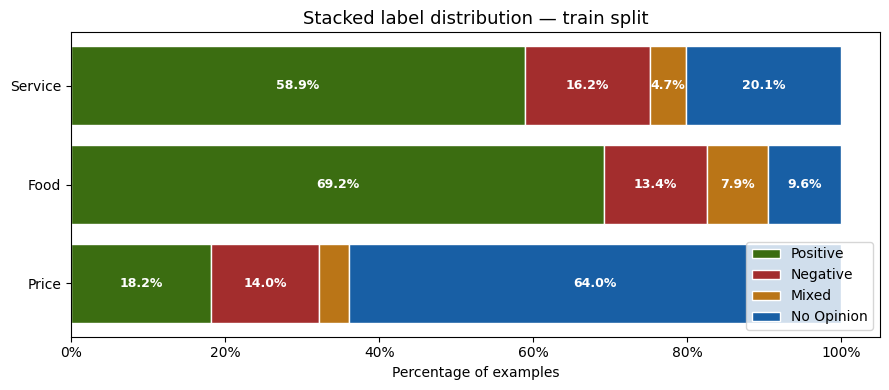

In [11]:
# Stacked bar — proportions across all 3 aspects side by side
fig, ax = plt.subplots(figsize=(9, 4))

pct_data = {}
for asp in ASPECTS:
    pct_data[asp] = train[asp + '_clean'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100

bottom = np.zeros(3)
for lbl in LABELS:
    vals = [pct_data[asp][lbl] for asp in ASPECTS]
    ax.barh(ASPECTS, vals, left=bottom, color=COLORS[lbl], label=lbl, edgecolor='white')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax.text(b + v/2, i, f'{v:.1f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += np.array(vals)

ax.set_xlabel('Percentage of examples')
ax.set_title('Stacked label distribution — train split', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

## 5 · Class imbalance metrics

In [37]:
print('Imbalance metrics per aspect (train):\n')
rows = []
for asp in ASPECTS:
    counts = train[asp + '_clean'].value_counts().reindex(LABELS, fill_value=0)
    majority_class = counts.idxmax()
    majority_pct   = counts.max() / counts.sum() * 100
    minority_class = counts.idxmin()
    minority_pct   = counts.min() / counts.sum() * 100
    imbalance_ratio = counts.max() / max(counts.min(), 1)
    naive_acc = counts.max() / counts.sum() * 100  # always-predict-majority accuracy
    rows.append({
        'Aspect':          asp,
        'Majority class':  majority_class,
        'Majority %':      round(majority_pct, 1),
        'Minority class':  minority_class,
        'Minority %':      round(minority_pct, 1),
        'Imbalance ratio': round(imbalance_ratio, 1),
        'Naive acc (%)':   round(naive_acc, 1),
    })

display(pd.DataFrame(rows).set_index('Aspect'))

In [38]:
# Macro-accuracy of always-predict-majority baseline (per-aspect then averaged)
naive_macro = np.mean([
    train[asp + '_clean'].value_counts(normalize=True).max() * 100
    for asp in ASPECTS
])
print(f'Naive majority-class macro accuracy baseline: {naive_macro:.1f}%')
print('Your model must significantly exceed this.')

## 6 · Train / Val distribution comparison

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Train vs Val label distribution per aspect', fontsize=13)

for ax, asp in zip(axes, ASPECTS):
    tr_pct = train[asp + '_clean'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100
    va_pct = val[asp + '_clean'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100

    x = np.arange(len(LABELS))
    w = 0.35
    ax.bar(x - w/2, tr_pct.values, w, label='Train', color='#534AB7', alpha=0.85)
    ax.bar(x + w/2, va_pct.values, w, label='Val',   color='#1D9E75', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, rotation=20, fontsize=9)
    ax.set_title(asp, fontweight='bold')
    ax.set_ylabel('%')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [40]:
# KL divergence between train and val distributions (lower = more similar)
from scipy.stats import entropy

print('KL divergence train → val (bits):')
for asp in ASPECTS:
    tr_p = train[asp + '_clean'].value_counts(normalize=True).reindex(LABELS, fill_value=1e-9)
    va_p = val[asp + '_clean'].value_counts(normalize=True).reindex(LABELS,   fill_value=1e-9)
    kl = entropy(tr_p, va_p)
    print(f'  {asp}: {kl:.4f}')

## 7 · Review length analysis

In [41]:
train['char_len']  = train['Review'].str.len()
train['word_len']  = train['Review'].str.split().str.len()
val['char_len']    = val['Review'].str.len()
val['word_len']    = val['Review'].str.split().str.len()

print('=== Character length statistics ===')
display(pd.concat({'Train': train['char_len'].describe(),
                   'Val':   val['char_len'].describe()}, axis=1).round(1))

print('\n=== Word count statistics ===')
display(pd.concat({'Train': train['word_len'].describe(),
                   'Val':   val['word_len'].describe()}, axis=1).round(1))

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['char_len'], bins=50, color='#534AB7', alpha=0.8, edgecolor='white')
axes[0].axvline(train['char_len'].median(), color='#A32D2D', linestyle='--', label=f"Median: {train['char_len'].median():.0f}")
axes[0].set_xlabel('Character length')
axes[0].set_ylabel('Count')
axes[0].set_title('Review length (chars) — train')
axes[0].legend()

axes[1].hist(train['word_len'], bins=40, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[1].axvline(train['word_len'].median(), color='#A32D2D', linestyle='--', label=f"Median: {train['word_len'].median():.0f}")
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Count')
axes[1].set_title('Review length (words) — train')
axes[1].legend()

plt.tight_layout()
plt.show()

In [43]:
# Approximate XLM-RoBERTa token count (rough heuristic: ~1.4 tokens per word for French)
# For exact counts, load the tokeniser — but that requires the model download
TOKENS_PER_WORD = 1.4
train['approx_tokens'] = (train['word_len'] * TOKENS_PER_WORD + 2).astype(int)  # +2 for [CLS],[SEP]

truncated = (train['approx_tokens'] > 512).sum()
print(f'Reviews likely exceeding 512 tokens: {truncated} / {len(train)} ({100*truncated/len(train):.1f}%)')
print(f'Max approx tokens: {train["approx_tokens"].max()}')
print()

if truncated > 0:
    print('Longest reviews (potentially truncated):')
    display(train.nlargest(5, 'approx_tokens')[['Review', 'approx_tokens', 'Price_clean', 'Food_clean', 'Service_clean']])

In [44]:
# Review length by label — do longer reviews contain more Mixed labels?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Review word count by label per aspect (train)', fontsize=13)

for ax, asp in zip(axes, ASPECTS):
    data_by_label = [train[train[asp + '_clean'] == lbl]['word_len'].values for lbl in LABELS]
    bp = ax.boxplot(data_by_label, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, lbl in zip(bp['boxes'], LABELS):
        patch.set_facecolor(COLORS[lbl])
        patch.set_alpha(0.85)
    ax.set_xticklabels(LABELS, rotation=20, fontsize=9)
    ax.set_title(asp, fontweight='bold')
    ax.set_ylabel('Word count')

plt.tight_layout()
plt.show()

## 8 · Label co-occurrence & correlation

In [45]:
# Encode labels as integers for correlation
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
for asp in ASPECTS:
    train[asp + '_id'] = train[asp + '_clean'].map(LABEL2ID)

corr_cols = [a + '_id' for a in ASPECTS]
corr_matrix = train[corr_cols].corr()
corr_matrix.index   = ASPECTS
corr_matrix.columns = ASPECTS

print('Pearson correlation between aspect label encodings (train):')
display(corr_matrix.round(3))

In [46]:
fig, ax = plt.subplots(figsize=(5, 4))
mask = np.eye(3, dtype=bool)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Blues',
            mask=mask, ax=ax, vmin=0, vmax=0.7,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Label correlation between aspects', fontsize=12)
plt.tight_layout()
plt.show()

In [47]:
# Cross-tabulation of label pairs
for i, asp1 in enumerate(ASPECTS):
    for asp2 in ASPECTS[i+1:]:
        print(f'\n{asp1} × {asp2} co-occurrence (train counts):')
        ct = pd.crosstab(train[asp1 + '_clean'], train[asp2 + '_clean'],
                         rownames=[asp1], colnames=[asp2])
        ct = ct.reindex(index=LABELS, columns=LABELS, fill_value=0)
        display(ct)

## 9 · Reviews with all 3 aspects as "No Opinion"

In [48]:
all_nop = train[(train['Price_clean'] == 'No Opinion') &
                (train['Food_clean']  == 'No Opinion') &
                (train['Service_clean'] == 'No Opinion')]

print(f'Reviews with No Opinion on ALL 3 aspects: {len(all_nop)} ({100*len(all_nop)/len(train):.1f}%)')
display(all_nop[['Review', 'Price_clean', 'Food_clean', 'Service_clean']].head(10))

## 10 · Vocabulary analysis

In [49]:
def tokenize_simple(text):
    """Basic whitespace+punctuation tokeniser — no external deps."""
    return re.findall(r'\b[a-zàâäéèêëîïôùûüœç]+\b', str(text).lower())

# French stopwords (minimal set)
STOPWORDS = {
    'le','la','les','de','du','des','un','une','et','en','à','au','aux',
    'est','sont','a','ont','je','il','elle','nous','vous','ils','elles',
    'que','qui','quoi','ce','se','sa','son','ses','mon','ma','mes',
    'pas','ne','plus','très','bien','y','on','leur','leurs','par',
    'pour','sur','avec','dans','mais','ou','si','car','tout','tous',
    'cette','cet','notre','nos','votre','vos','aussi','même','comme',
    'j','c','d','l','m','n','s','qu','cela','ça',
}

print('Vocabulary per label class for each aspect:')
print('(top 20 most frequent words, stopwords removed)\n')

In [50]:
# Most common words per label, per aspect
fig, axes = plt.subplots(len(ASPECTS), len(LABELS), figsize=(20, 12))
fig.suptitle('Top 20 words per label per aspect (train, stopwords removed)', fontsize=13)

TOP_N = 20

for i, asp in enumerate(ASPECTS):
    for j, lbl in enumerate(LABELS):
        ax = axes[i][j]
        subset = train[train[asp + '_clean'] == lbl]['Review']
        words = [w for text in subset for w in tokenize_simple(text) if w not in STOPWORDS and len(w) > 2]
        freq = Counter(words).most_common(TOP_N)
        if not freq:
            ax.axis('off')
            continue
        terms, counts = zip(*freq)
        ax.barh(range(len(terms)), counts, color=COLORS[lbl], alpha=0.8)
        ax.set_yticks(range(len(terms)))
        ax.set_yticklabels(terms, fontsize=8)
        ax.invert_yaxis()
        ax.set_title(f'{asp} — {lbl}\n(n={len(subset)})', fontsize=9, fontweight='bold')
        ax.tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

In [51]:
# Words most discriminative for Mixed label vs the rest (simple frequency ratio)
print('Words with highest frequency in Mixed reviews vs all others (per aspect):\n')

for asp in ASPECTS:
    mixed_reviews = train[train[asp + '_clean'] == 'Mixed']['Review']
    other_reviews = train[train[asp + '_clean'] != 'Mixed']['Review']

    mixed_words = Counter(w for t in mixed_reviews for w in tokenize_simple(t)
                          if w not in STOPWORDS and len(w) > 2)
    other_words = Counter(w for t in other_reviews for w in tokenize_simple(t)
                          if w not in STOPWORDS and len(w) > 2)

    n_mixed = max(sum(mixed_words.values()), 1)
    n_other = max(sum(other_words.values()), 1)

    ratios = {
        w: (mixed_words[w] / n_mixed) / max(other_words.get(w, 1) / n_other, 1e-9)
        for w in mixed_words if mixed_words[w] >= 3
    }
    top = sorted(ratios.items(), key=lambda x: -x[1])[:15]
    print(f'{asp}: {[w for w, _ in top]}')

## 11 · Duplicate & near-duplicate reviews

In [52]:
# Exact duplicates
exact_dups = train[train.duplicated(subset=['Review'], keep=False)]
print(f'Exact duplicate reviews in train: {len(exact_dups)} ({100*len(exact_dups)/len(train):.1f}%)')
if len(exact_dups):
    display(exact_dups[['Review', 'Price_clean', 'Food_clean', 'Service_clean']].head(10))

In [53]:
# Train/val overlap (same review text in both splits — data leak check)
train_texts = set(train['Review'].str.strip())
val_texts   = set(val['Review'].str.strip())
overlap     = train_texts & val_texts
print(f'Reviews present in BOTH train and val: {len(overlap)}')
if overlap:
    print('Examples:')
    for t in list(overlap)[:5]:
        print(' >', t[:100])

## 12 · Restaurant-level analysis

In [54]:
# Infer restaurant column name
restaurant_col = [c for c in train.columns if c not in ASPECTS + ['Review'] + CLEAN + 
                  [a+'_id' for a in ASPECTS] + ['char_len','word_len','approx_tokens']]
print('Non-aspect, non-review columns (likely restaurant identifier):', restaurant_col)

if restaurant_col:
    rcol = restaurant_col[0]
    print(f'\nUnique restaurants in train: {train[rcol].nunique()}')
    print(f'Unique restaurants in val:   {val[rcol].nunique()}')
    print(f'Reviews per restaurant (train):')
    display(train[rcol].value_counts().describe().round(1))

    # Restaurants appearing in both splits
    shared_restaurants = set(train[rcol]) & set(val[rcol])
    print(f'\nRestaurants in both train and val: {len(shared_restaurants)}')

In [55]:
if restaurant_col:
    rcol = restaurant_col[0]
    # Reviews per restaurant histogram
    fig, ax = plt.subplots(figsize=(8, 4))
    rev_counts = train[rcol].value_counts()
    ax.hist(rev_counts.values, bins=30, color='#534AB7', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Reviews per restaurant')
    ax.set_ylabel('Number of restaurants')
    ax.set_title('Distribution of review count per restaurant (train)')
    ax.axvline(rev_counts.median(), color='#A32D2D', linestyle='--',
               label=f'Median: {rev_counts.median():.0f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 13 · Sample reviews per label combination

In [56]:
# Show random samples for interesting / rare label combinations
combos = [
    ('All Positive',      {'Price_clean': 'Positive', 'Food_clean': 'Positive', 'Service_clean': 'Positive'}),
    ('All Negative',      {'Price_clean': 'Negative', 'Food_clean': 'Negative', 'Service_clean': 'Negative'}),
    ('All No Opinion',    {'Price_clean': 'No Opinion', 'Food_clean': 'No Opinion', 'Service_clean': 'No Opinion'}),
    ('Food Mixed',        {'Food_clean': 'Mixed'}),
    ('Service Mixed',     {'Service_clean': 'Mixed'}),
    ('Price Mixed',       {'Price_clean': 'Mixed'}),
    ('Food Pos, Svc Neg', {'Food_clean': 'Positive', 'Service_clean': 'Negative'}),
]

pd.set_option('display.max_colwidth', 200)
for name, filters in combos:
    mask = pd.Series([True] * len(train), index=train.index)
    for col, val in filters.items():
        mask &= (train[col] == val)
    subset = train[mask]
    print(f'\n--- {name} (n={len(subset)}) ---')
    if len(subset):
        sample = subset.sample(min(3, len(subset)), random_state=42)
        display(sample[['Review', 'Price_clean', 'Food_clean', 'Service_clean']])

## 14 · (Optional) Exact token counts with XLM-RoBERTa tokeniser

In [ ]:
# Uncomment to run — requires the model to be downloaded

# from transformers import AutoTokenizer
# tokenizer = AutoTokenizer.from_pretrained('FacebookAI/xlm-roberta-base')

# def count_tokens(text):
#     return len(tokenizer.encode(text, truncation=False))

# train['token_len'] = train['Review'].apply(count_tokens)
# val['token_len']   = val['Review'].apply(count_tokens)

# print(train['token_len'].describe().round(1))
# truncated = (train['token_len'] > 512).sum()
# print(f'Reviews exceeding 512 tokens: {truncated} ({100*truncated/len(train):.1f}%)')

# fig, ax = plt.subplots(figsize=(9, 4))
# ax.hist(train['token_len'], bins=50, color='#534AB7', alpha=0.8, edgecolor='white')
# ax.axvline(512, color='red', linestyle='--', label='512-token limit')
# ax.axvline(train['token_len'].median(), color='#3B6D11', linestyle='--',
#            label=f"Median: {train['token_len'].median():.0f}")
# ax.set_xlabel('Token count (xlm-roberta-base)')
# ax.set_ylabel('Number of reviews')
# ax.set_title('Exact token length distribution — train')
# ax.legend()
# plt.tight_layout()
# plt.show()

print('Uncomment the block above to run exact token counts.')

## 15 · Summary table

In [57]:
print('=== DATASET SUMMARY ===')
print(f'Train size:  {len(train)}')
print(f'Val size:    {len(val)}')
print(f'Test size:   {len(test) if test is not None else "unknown (held-out)"}')
print(f'Total aspects: 3 (Price, Food, Service)')
print(f'Classes per aspect: 4 (Positive, Negative, Mixed, No Opinion)')
print(f'Total output combinations possible: 4^3 = 64')
print()

print('Actual label combinations observed in train:')
combo_counts = train.groupby(['Price_clean','Food_clean','Service_clean']).size().sort_values(ascending=False)
print(f'  {len(combo_counts)} distinct combinations out of 64 possible')
print()
print('Top 10 most frequent:')
display(combo_counts.head(10).reset_index(name='count'))
print('\nRarest (bottom 10):')
display(combo_counts.tail(10).reset_index(name='count'))